# Minecraft Skin Classifier – Final Modelling Notebook

**Course:** Machine Learning (ITS/AIS/BIN) – FH Salzburg  
**Date:** May 2026  

---

## 1. Problem Statement (Business Understanding)

### What are we solving?

Minecraft servers often need to automatically detect skins that violate copyright or community guidelines  
(e.g. skins depicting Spider-Man, other licensed characters, or inappropriate content).  
Manual review is not scalable – a Minecraft server can have thousands of players.

**Goal:** Build a binary image classifier that automatically flags a Minecraft skin as:  
- **Class 0 – normal** (generic, community-created skin)  
- **Class 1 – flagged** (depicts a copyrighted / banned character, e.g. Spider-Man)

### Why does recall matter more than precision here?

A **false negative** (flagged skin classified as normal) means a banned skin slips through → real harm.  
A **false positive** (normal skin flagged as bad) means an unfair temporary ban → recoverable harm.  

Therefore we optimize **recall** (sensitivity) while keeping precision acceptable.  
We will tune the classification **threshold** accordingly after training.

### Why CNN?

Minecraft skins are 64×64 RGBA pixel images where **spatial structure is fixed**  
(head always top-left, body always center, etc.).  
CNNs exploit local spatial correlations via shared convolutional filters, making them the natural  
choice for structured image data. They learn hierarchical features (edges → textures → shapes)  
without hand-crafted feature engineering.

Unlike a fully connected network, a CNN uses **weight sharing** and **local receptive fields**,  
which drastically reduces parameters and improves generalization on small datasets.

---
## 2. Setup & Imports

We use **TensorFlow/Keras** for the deep learning pipeline and **scikit-learn** for evaluation metrics.  
All random seeds are fixed for reproducibility.

In [263]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_recall_curve
)
from sklearn.model_selection import train_test_split

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


---
## 3. Central Configuration

**Design decision:** All tunable parameters are defined here in one place.  
This makes the notebook easy to re-run with different settings without hunting through code.  
It also documents every hyperparameter choice explicitly.

In [264]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path("./../")                          # project root
GOOD_DIR    = ROOT / "data" / "skins" / "good"       # class 0: normal skins
BAD_DIR     = ROOT / "data" / "skins" / "bad" / "spiderman"        # class 1: flagged skins
MODEL_PATH  = ROOT / "04_Modeling" / "best_model.keras"

# ── Image properties ──────────────────────────────────────────────────────────
IMG_SIZE    = (64, 64)   # Minecraft skins are always 64x64
N_CHANNELS  = 4          # RGBA – alpha channel encodes transparency (skin regions vs empty)

# class imbalance
N_IMAGES_PER_CLASS = 1000

# ── Dataset split ─────────────────────────────────────────────────────────────
# 70 % train / 15 % val / 15 % test  →  standard split for medium-sized datasets
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE  = 32         # small enough for memory, large enough for stable gradients
MAX_EPOCHS  = 60         # EarlyStopping will terminate earlier if needed
PATIENCE    = 10         # epochs without val_loss improvement before stopping
LR_INIT     = 3e-4       # Adam default – works well as starting point
LR_FACTOR   = 0.5        # halve LR on plateau
LR_PATIENCE = 3          # epochs before LR reduction

print("Configuration loaded.")
print(f"  Good skins dir : {GOOD_DIR}")
print(f"  Bad  skins dir : {BAD_DIR}")
print(f"  Image size     : {IMG_SIZE}, channels: {N_CHANNELS}")

Configuration loaded.
  Good skins dir : ..\data\skins\good
  Bad  skins dir : ..\data\skins\bad\spiderman
  Image size     : (64, 64), channels: 4


---
## 4. Data Loading

We load all `.png` files from `good/` (label 0) and all `.png` files recursively from `bad/` (label 1).  
The `bad/` directory contains one subdirectory per keyword (e.g. `spiderman/`), so we glob recursively.

### Why do we keep the alpha channel?

The Minecraft skin format uses the **alpha channel** as a mask – it encodes which pixels are part of
the skin vs. transparent (unused) regions. Discarding it would lose structural information that could  
help the model distinguish character skins (which often have distinctive transparency patterns).

In [265]:
def collect_image_paths(good_dir: Path, bad_dir: Path):
    """Collect all PNG paths and assign binary labels (0=good, 1=bad)."""
    good_paths = sorted(good_dir.glob("*.png"))[:N_IMAGES_PER_CLASS]
    bad_paths  = sorted(bad_dir.rglob("*.png"))[:N_IMAGES_PER_CLASS]   # recursive → picks up all keyword subdirs

    paths  = good_paths + bad_paths
    labels = [0] * len(good_paths) + [1] * len(bad_paths)

    print(f"Good skins (class 0): {len(good_paths):,}")
    print(f"Bad  skins (class 1): {len(bad_paths):,}")
    print(f"Total               : {len(paths):,}")
    print(f"Class ratio bad/good: {len(bad_paths)/len(good_paths):.2f}")
    return paths, labels

all_paths, all_labels = collect_image_paths(GOOD_DIR, BAD_DIR)

Good skins (class 0): 1,000
Bad  skins (class 1): 1,000
Total               : 2,000
Class ratio bad/good: 1.00


In [266]:
def load_images(paths, img_size=(64, 64)):
    """
    Load PNG images as float32 numpy arrays normalized to [0, 1].

    Normalization to [0,1]:
    - Dividing by 255 brings all pixel values into the same range.
    - This is standard practice for neural networks and prevents large
      gradient magnitudes during training (numerical stability).
    """
    imgs = []
    for p in paths:
        img = tf.keras.utils.load_img(str(p), color_mode="rgba", target_size=img_size)
        arr = tf.keras.utils.img_to_array(img) / 255.0   # normalize to [0, 1]
        imgs.append(arr)
    return np.array(imgs, dtype=np.float32)

print("Loading images... (this may take a moment)")
X = load_images(all_paths)
y = np.array(all_labels, dtype=np.float32)

print(f"\nX shape: {X.shape}  →  (samples, height, width, channels)")
print(f"y shape: {y.shape}")
print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}]")

Loading images... (this may take a moment)

X shape: (2000, 64, 64, 4)  →  (samples, height, width, channels)
y shape: (2000,)
Pixel value range: [0.00, 1.00]


---
## 5. Exploratory Data Analysis

Before modelling we inspect the data to understand:
- **Class distribution** (imbalance?)
- **Visual appearance** of samples from each class
- **Pixel statistics** (mean, std per class)

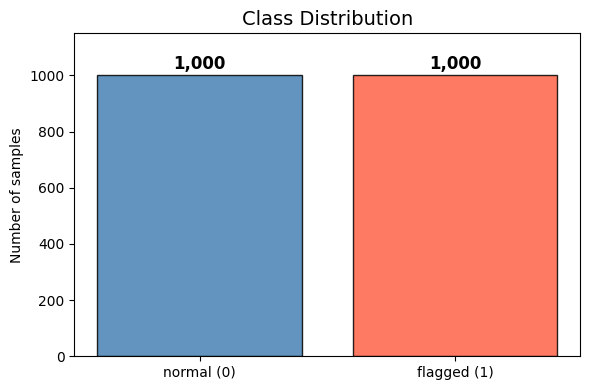

Imbalance ratio (bad/good): 1.00
→ A ratio far from 1.0 requires class-weighting during training.


In [267]:
# ── Class distribution ────────────────────────────────────────────────────────
class_counts = pd.Series(y).value_counts().sort_index()
class_names  = ["normal (0)", "flagged (1)"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_names, class_counts.values, color=["steelblue", "tomato"], alpha=0.85, edgecolor="black")
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{count:,}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_title("Class Distribution", fontsize=14)
ax.set_ylabel("Number of samples")
ax.set_ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[1] / class_counts[0]
print(f"Imbalance ratio (bad/good): {imbalance_ratio:.2f}")
print("→ A ratio far from 1.0 requires class-weighting during training.")

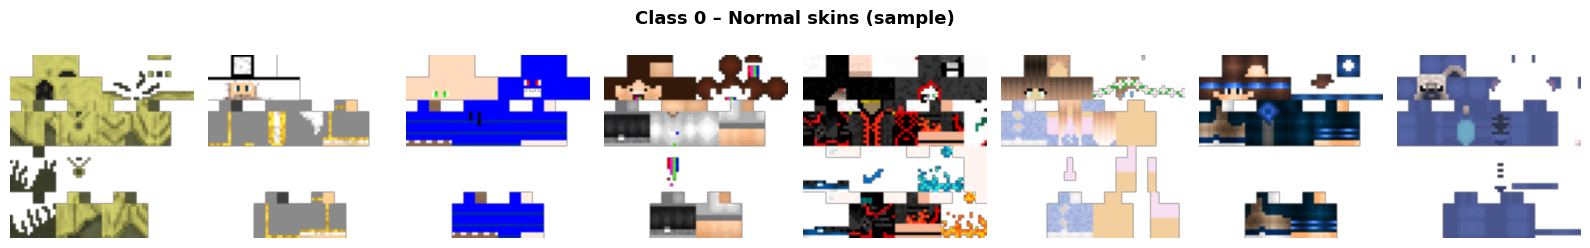

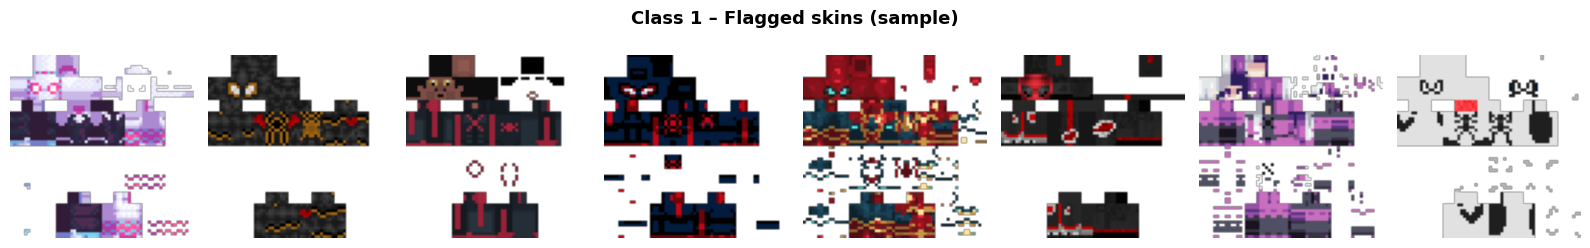

In [268]:
# ── Visual inspection – sample images per class ───────────────────────────────
def show_samples(X, y, label, n=8, title=""):
    indices = np.where(y == label)[0]
    chosen  = np.random.choice(indices, size=min(n, len(indices)), replace=False)

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for ax, idx in zip(axes, chosen):
        # Display only RGB channels for readability (drop alpha for visualisation)
        ax.imshow(X[idx, :, :, :4])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(X, y, label=0, n=8, title="Class 0 – Normal skins (sample)")
show_samples(X, y, label=1, n=8, title="Class 1 – Flagged skins (sample)")

Normal skins | mean pixel: 0.258 | std: 0.389
Flagged skins | mean pixel: 0.213 | std: 0.359


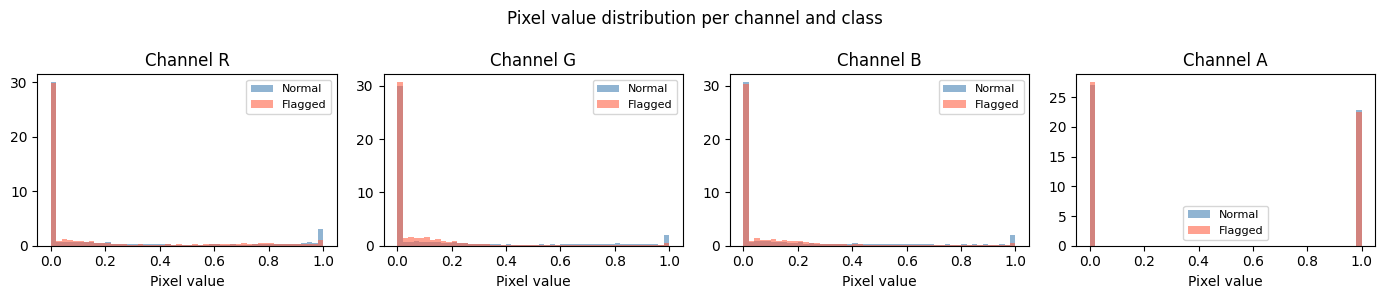

In [269]:
# ── Pixel statistics per class ────────────────────────────────────────────────
# Understanding the average pixel intensities helps explain why a CNN can
# distinguish the classes – flagged character skins often have distinctive
# color distributions (e.g. red/blue for Spider-Man).

for label, name in [(0, "Normal"), (1, "Flagged")]:
    subset = X[y == label]
    print(f"{name} skins | mean pixel: {subset.mean():.3f} | std: {subset.std():.3f}")

channel_names = ["R", "G", "B", "A"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ch, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    ax.hist(X[y == 0, :, :, ch].ravel(), bins=50, alpha=0.6, color="steelblue", label="Normal", density=True)
    ax.hist(X[y == 1, :, :, ch].ravel(), bins=50, alpha=0.6, color="tomato",    label="Flagged", density=True)
    ax.set_title(f"Channel {ch_name}")
    ax.set_xlabel("Pixel value")
    ax.legend(fontsize=8)
plt.suptitle("Pixel value distribution per channel and class", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Train / Validation / Test Split

We use a **stratified** split to ensure the class ratio is preserved in all three sets.  
This is critical when classes are imbalanced.

- **Training set (70%)** – used for gradient updates  
- **Validation set (15%)** – used to monitor generalization during training (early stopping, LR scheduling)  
- **Test set (15%)** – held out until final evaluation; never influences any training decision

In [270]:
# First: split off test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SPLIT,
    stratify=y,         # preserve class ratio
    random_state=SEED
)

# Then: split training into train + validation
val_relative = VAL_SPLIT / (1 - TEST_SPLIT)   # recalculate fraction relative to trainval
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_relative,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Train : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]:,} samples  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass 1 ratio in train: {y_train.mean():.3f}")
print(f"Class 1 ratio in val  : {y_val.mean():.3f}")
print(f"Class 1 ratio in test : {y_test.mean():.3f}")

Train : 1,400 samples  (70%)
Val   : 300 samples  (15%)
Test  : 300 samples  (15%)

Class 1 ratio in train: 0.500
Class 1 ratio in val  : 0.500
Class 1 ratio in test : 0.500


---
## 7. Handling Class Imbalance – Class Weights

### Problem

If Class 0 has far more samples than Class 1, a naïve model can achieve high accuracy  
simply by predicting Class 0 for every sample. This is called the **majority-class baseline**.

### Solution: Inverse-frequency class weights

We compute weights `w_k = total_samples / (n_classes × count_k)` for each class k.  
These weights are passed to `model.fit()` so that errors on the minority class  
count proportionally more in the loss function.  

This is equivalent to **oversampling** the minority class in expectation,  
but requires no data duplication.

In [271]:
n_total  = len(y_train)
n_good   = int((y_train == 0).sum())
n_bad    = int((y_train == 1).sum())
n_classes = 2

# Sklearn-style inverse-frequency weighting
class_weights = {
    0: n_total / (n_classes * n_good),
    1: n_total / (n_classes * n_bad),
}

print("Class weights:")
print(f"  Class 0 (normal) : {class_weights[0]:.4f}")
print(f"  Class 1 (flagged): {class_weights[1]:.4f}")
print()
print("Interpretation: misclassifying a flagged skin costs",
      f"{class_weights[1]/class_weights[0]:.1f}x more than misclassifying a normal skin.")

Class weights:
  Class 0 (normal) : 1.0000
  Class 1 (flagged): 1.0000

Interpretation: misclassifying a flagged skin costs 1.0x more than misclassifying a normal skin.


In [272]:
## apply weights


---
## 8. Data Augmentation

TODO: Move to Data Preparation

### Why augment?

Augmentation artificially increases training diversity, which reduces overfitting  
and improves generalization to unseen skins.

### What NOT to do with Minecraft skins

Standard augmentations like **horizontal flipping**, **rotation**, or **translation**  
would **break the semantic structure** of a Minecraft skin.  
The skin format has fixed pixel regions (head: top-left 32×16 area, body: center, etc.).  
Shifting the image would move, e.g., the head region into the arm region, creating  
nonsensical inputs that confuse the model.

### What we do instead

- **Brightness jitter** (±10%): simulates lighting/texture variation  
- **Channel shift / hue perturbation**: the exact color hue is less class-discriminative  
  than the pattern shape  

Both augmentations are applied **only to the training set**, never to val/test,  
because validation and test must reflect the real-world data distribution.

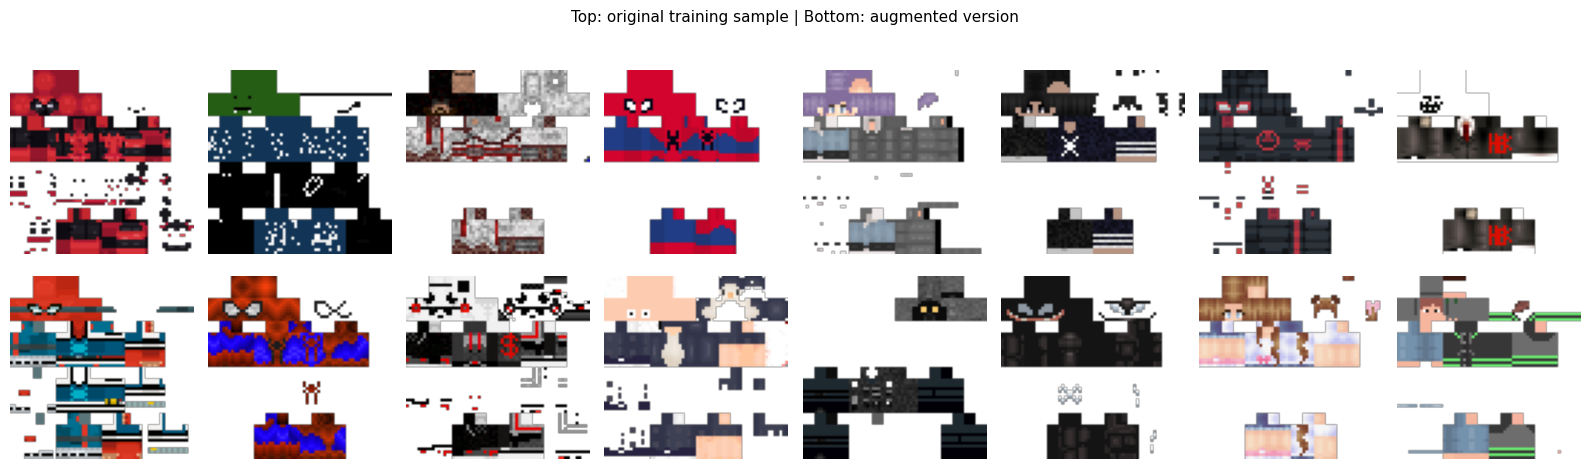

In [273]:
# Trennen — channels_last, daher [..., :3] und [..., 3:4]
X_train_rgb   = X_train[..., :3]    # (1400, 64, 64, 3)
X_train_alpha = X_train[..., 3:4]   # (1400, 64, 64, 1)

train_datagen = ImageDataGenerator(
    channel_shift_range=25/255,
    #brightness_range=[0.4, 1.2] # TODO: doesnt work
)

rgb_gen   = train_datagen.flow(X_train_rgb,   y_train, batch_size=BATCH_SIZE, seed=SEED)
alpha_gen = ImageDataGenerator().flow(X_train_alpha, y_train, batch_size=BATCH_SIZE, seed=SEED)

def rgba_generator(rgb_gen, alpha_gen):
    for (rgb_batch, labels), (alpha_batch, _) in zip(rgb_gen, alpha_gen):
        rgba_batch = np.concatenate([rgb_batch, alpha_batch], axis=-1)  # (B, 64, 64, 4)
        yield rgba_batch, labels

train_gen = rgba_generator(rgb_gen, alpha_gen)
val_gen   = ImageDataGenerator().flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

# Visualize augmented samples to verify correctness
sample_batch_X, sample_batch_y = next(train_gen)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Top: original training sample | Bottom: augmented version", fontsize=11)
for i in range(8):
    axes[0, i].imshow(X_train[i, :, :, :4])
    axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(sample_batch_X[i, :, :, :4], 0, 1))
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

---
## 9. Baseline Model

Before training a neural network, we establish a **baseline** – the simplest possible model.  
This serves as a reference: our CNN must clearly outperform it to justify its complexity.

**Majority class baseline:** predict the most frequent class for every input.  
It requires no training but reveals the naive upper bound for accuracy on imbalanced data.

In [274]:
majority_class   = int(np.round(y_train.mean()))   # 0 if >50% good, 1 if >50% bad
baseline_preds   = np.full(len(y_test), majority_class)
baseline_acc     = (baseline_preds == y_test).mean()
baseline_recall  = ((baseline_preds == 1) & (y_test == 1)).sum() / (y_test == 1).sum()

print("=== Majority Class Baseline ===")
print(f"Always predicts class : {majority_class}")
print(f"Accuracy              : {baseline_acc:.3f}")
print(f"Recall (class 1)      : {baseline_recall:.3f}")
print()
print("→ Our CNN must beat this baseline significantly in both accuracy and recall.")

=== Majority Class Baseline ===
Always predicts class : 0
Accuracy              : 0.500
Recall (class 1)      : 0.000

→ Our CNN must beat this baseline significantly in both accuracy and recall.


---
## 10. CNN Architecture – Design & Rationale

### Architecture choices explained

| Component | Choice | Reasoning |
|---|---|---|
| **Conv2D 3×3 kernels** | Small kernels | Capture local patterns efficiently; standard in modern CNNs (VGG, ResNet) |
| **ReLU activation** | Non-linearity | Computationally efficient, avoids vanishing gradient better than sigmoid/tanh |
| **Batch Normalization** | After each Conv | Normalises layer inputs → more stable training, allows higher learning rates |
| **MaxPooling 2×2** | Spatial downsampling | Halves spatial resolution → increases receptive field, reduces parameters |
| **Dropout (0.3)** | After pooling blocks | Randomly disables 30% of neurons → prevents overfitting on small dataset |
| **GlobalAveragePooling** | Instead of Flatten | Reduces parameters dramatically; less prone to overfitting than Flatten+Dense |
| **Sigmoid output** | Binary classification | Maps final logit to probability in [0, 1] |
| **Binary crossentropy** | Loss function | Standard for binary classification; compatible with sigmoid output |

### Growing filter depth (32 → 64 → 128)

Early layers detect low-level features (edges, colors) → fewer filters needed.  
Deeper layers detect complex patterns (character shapes) → more filters needed.  
Doubling filters per block is the standard practice (VGGNet design principle).

In [275]:
def build_model(input_shape=(64, 64, 4)) -> tf.keras.Model:
    """
    Builds a CNN for binary Minecraft skin classification.

    Architecture: 3 convolutional blocks (Conv→BN→Conv→BN→Pool→Dropout)
    followed by GlobalAveragePooling and a Dense sigmoid head.
    """
    model = Sequential([
        Input(shape=input_shape),

        # ── Block 1: Extract low-level features (edges, colors) ──────────────
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),   # 64×64 → 32×32
        Dropout(0.4),

        # ── Block 2: Extract mid-level patterns (textures, shapes) ───────────
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),   # 32×32 → 16×16
        Dropout(0.4),

        # ── Block 3: High-level representations (character features) ─────────
        Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),   # 16×16 → 8×8
        Dropout(0.4),

        # ── Classifier head ───────────────────────────────────────────────────
        GlobalAveragePooling2D(),   # averages spatial maps → 128-dim vector, fewer params
        Dense(64, activation="relu"),
        Dropout(0.6),               # higher dropout in dense head (most overfitting risk)
        Dense(1, activation="sigmoid"),  # binary probability output
    ], name="minecraft_skin_cnn")

    return model


model = build_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], N_CHANNELS))
model.summary()

Model: "minecraft_skin_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 64, 64, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 297,409 (1.13 MB)

 Trainable params: 296,513 (1.13 MB)

 Non-trainable params: 896 (3.50 KB)

---
## 11. Model Compilation

### Optimizer: Adam

Adam (Adaptive Moment Estimation) maintains per-parameter learning rates  
and adapts them based on first and second moments of gradients.  
It converges faster than vanilla SGD and requires minimal tuning.  
Starting LR of `1e-3` is the well-established Adam default.

### Metrics tracked during training

- **AUC** – threshold-independent; best single metric for imbalanced classification  
- **Precision / Recall** – directly measure false-positive and false-negative rates  
- **Accuracy** – kept for comparison with baseline

In [276]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_INIT),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

print("Model compiled.")
print(f"Trainable parameters: {model.count_params():,}")

Model compiled.
Trainable parameters: 297,409


---
## 12. Training Callbacks

Callbacks are functions that run at the end of each epoch and allow us to control training dynamically.

| Callback | Purpose |
|---|---|
| **EarlyStopping** | Stop training when val_loss stops improving → prevents overfitting |
| **ReduceLROnPlateau** | Halve the learning rate if val_loss stagnates → helps escape local minima |
| **ModelCheckpoint** | Save the weights of the best epoch → we can reload the best model after training |

In [277]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,   # revert to best epoch after stopping
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]

print("Callbacks configured:")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


---
## 13. Model Training

We pass `class_weight` to give the minority class proportionally higher loss.  
Training will stop automatically when the validation loss stops improving (EarlyStopping).

In [278]:
steps_per_epoch = len(X_train) // BATCH_SIZE

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=MAX_EPOCHS,
    validation_data=(X_val, y_val),
    #class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nTraining stopped after {len(history.history['loss'])} epochs.")

Epoch 1/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.6937 - auc: 0.7577 - loss: 0.6619 - precision: 0.6884 - recall: 0.7095 - val_accuracy: 0.5000 - val_auc: 0.7934 - val_loss: 0.7656 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - accuracy: 0.7936 - auc: 0.8600 - loss: 0.5163 - precision: 0.7812 - recall: 0.8174 - val_accuracy: 0.6033 - val_auc: 0.8157 - val_loss: 0.7070 - val_precision: 0.8444 - val_recall: 0.2533 - learning_rate: 3.0000e-04
Epoch 3/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.8180 - auc: 0.8958 - loss: 0.4453 - precision: 0.8263 - recall: 0.8032 - val_accuracy: 0.6167 - val_auc: 0.7493 - val_loss: 0.6898 - val_precision: 0.5709 - val_recall: 0.9400 - learning_rate: 3.0000e-04
Epoch 4/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.8377 - auc: 0.9096 - loss: 0.4217 - precision: 0.8545 - recall: 0.8118 - val_accuracy: 0.5367 - val_auc: 0.8138 - val_loss:

---
## 14. Training Curves

We plot loss and key metrics over epochs to assess:
- Whether the model **converged** (curves flatten)
- Whether there is **overfitting** (train improves, val stagnates or worsens)
- Whether **early stopping** triggered at the right point

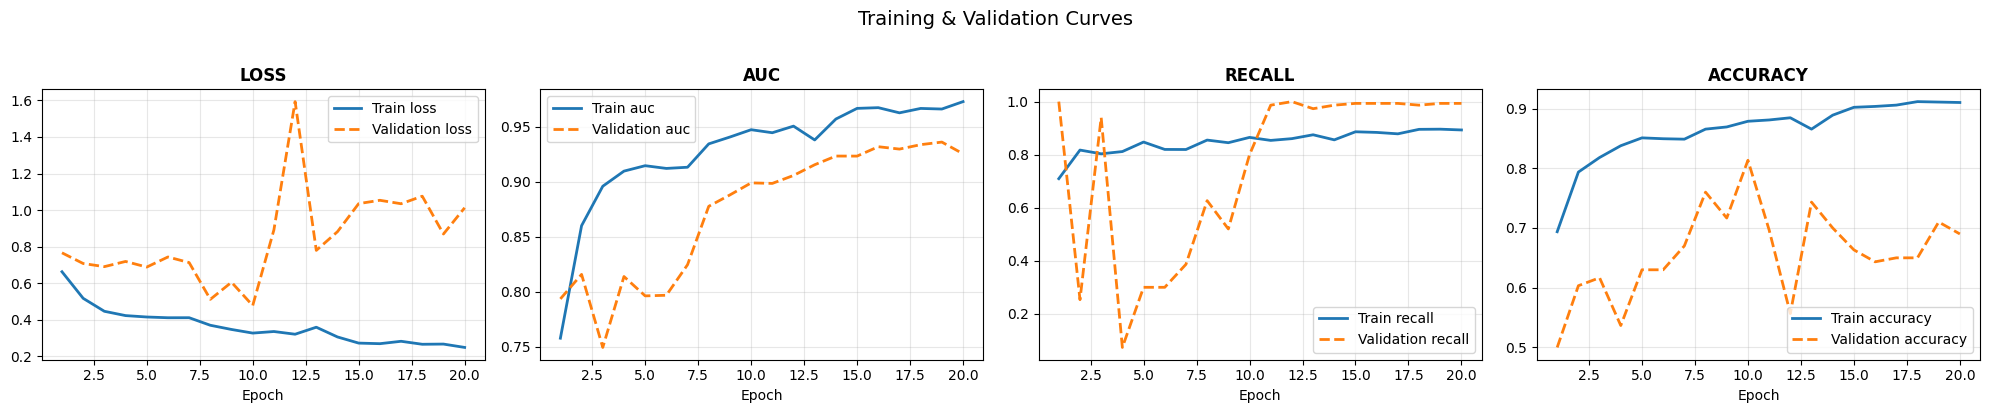

In [279]:
def plot_history(history, metrics=("loss", "auc", "recall", "accuracy")):
    """Plot training and validation curves for the given metrics."""
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    epochs = range(1, len(history.history["loss"]) + 1)

    for ax, metric in zip(axes, metrics):
        ax.plot(epochs, history.history[metric],          label=f"Train {metric}",      linewidth=2)
        ax.plot(epochs, history.history[f"val_{metric}"], label=f"Validation {metric}", linewidth=2, linestyle="--")
        ax.set_title(metric.upper(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training & Validation Curves", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history)

---
## 15. Evaluation on Test Set

We now evaluate the model on the **held-out test set** – data the model has never seen  
in any form (not for training, not for early stopping, not for LR scheduling).

This gives an unbiased estimate of real-world performance.

In [280]:
# Get predicted probabilities (not hard labels yet)
y_prob = model.predict(X_test, verbose=0).ravel()

# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)

# Metrics
auc  = roc_auc_score(y_test, y_prob)
print("=" * 45)
print(f"AUC-ROC         : {auc:.4f}")
print("=" * 45)
print(classification_report(y_test, y_pred_default, target_names=["normal", "flagged"]))

AUC-ROC         : 0.8582
              precision    recall  f1-score   support

      normal       0.74      0.88      0.80       150
     flagged       0.85      0.69      0.76       150

    accuracy                           0.78       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.79      0.78      0.78       300



### Confusion Matrix

The confusion matrix shows the four types of predictions:
- **True Negatives (TN)**: correctly classified as normal  
- **False Positives (FP)**: normal skin wrongly flagged → minor inconvenience  
- **False Negatives (FN)**: flagged skin missed → ⚠️ the error we most want to minimize  
- **True Positives (TP)**: correctly detected flagged skin

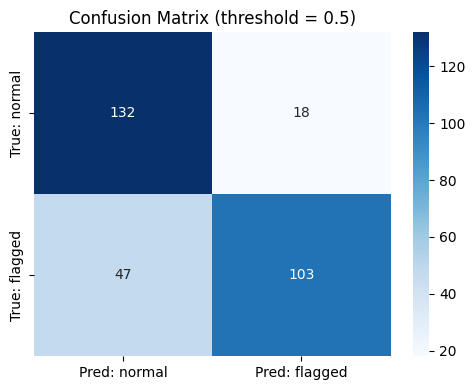

True Negatives (correct normal) : 132
False Positives (normal→flagged): 18  ← recoverable error
False Negatives (flagged→normal): 47  ← ⚠️ critical error
True Positives (correct flagged): 103


In [281]:
cm = confusion_matrix(y_test, y_pred_default)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title("Confusion Matrix (threshold = 0.5)", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct normal) : {tn}")
print(f"False Positives (normal→flagged): {fp}  ← recoverable error")
print(f"False Negatives (flagged→normal): {fn}  ← ⚠️ critical error")
print(f"True Positives (correct flagged): {tp}")

---
## 16. Threshold Tuning

The default decision threshold of **0.5** is not always optimal, especially when  
one error type is more costly than the other.

Since we want to **maximise recall** (catch as many flagged skins as possible)  
we sweep all possible thresholds and find the one that maximises F1-score on the **validation set**.  
Using the validation set (not test set) for threshold tuning prevents data leakage.

The **Precision-Recall curve** shows the trade-off: lowering the threshold  
increases recall but decreases precision.

Best threshold (max F1 on val): 0.265
  → F1       : 0.8359
  → Recall   : 0.9000
  → Precision: 0.7803


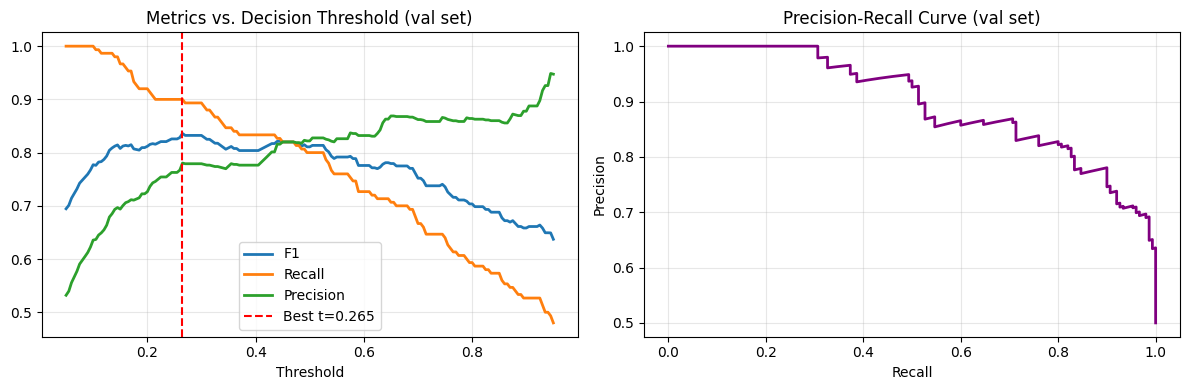

In [282]:
# --- 1. Compute threshold sweep on VALIDATION set ---
y_prob_val = model.predict(X_val, verbose=0).ravel()

thresholds = np.linspace(0.05, 0.95, 181)
results = []
for t in thresholds:
    y_hat = (y_prob_val >= t).astype(int)
    f1  = f1_score(y_val, y_hat, zero_division=0)
    rec = ((y_hat == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    pre = ((y_hat == 1) & (y_val == 1)).sum() / max((y_hat == 1).sum(), 1)
    results.append({"threshold": t, "f1": f1, "recall": rec, "precision": pre})

results_df  = pd.DataFrame(results)
best_row    = results_df.loc[results_df["f1"].idxmax()]
BEST_THRESH = best_row["threshold"]

print(f"Best threshold (max F1 on val): {BEST_THRESH:.3f}")
print(f"  → F1       : {best_row['f1']:.4f}")
print(f"  → Recall   : {best_row['recall']:.4f}")
print(f"  → Precision: {best_row['precision']:.4f}")

# --- 2. Visualise the sweep ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# F1 / Recall / Precision vs Threshold
axes[0].plot(results_df["threshold"], results_df["f1"],        label="F1",        linewidth=2)
axes[0].plot(results_df["threshold"], results_df["recall"],    label="Recall",    linewidth=2)
axes[0].plot(results_df["threshold"], results_df["precision"], label="Precision", linewidth=2)
axes[0].axvline(BEST_THRESH, color="red", linestyle="--", label=f"Best t={BEST_THRESH:.3f}")
axes[0].set_xlabel("Threshold")
axes[0].set_title("Metrics vs. Decision Threshold (val set)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_prob_val)
axes[1].plot(rec_curve, prec_curve, linewidth=2, color="purple")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (val set)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Final Test Evaluation (threshold = 0.265) ===
              precision    recall  f1-score   support

      normal       0.76      0.73      0.75       150
     flagged       0.74      0.77      0.75       150

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300



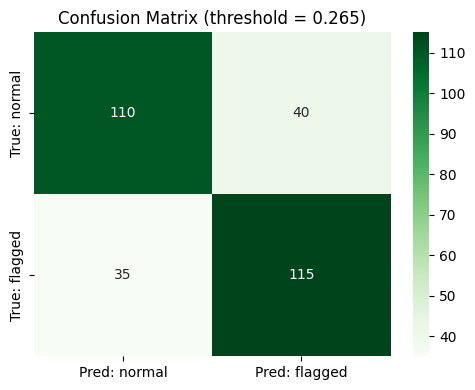

In [283]:
# ── Final evaluation on TEST set with tuned threshold ────────────────────────
y_pred_tuned = (y_prob >= BEST_THRESH).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"=== Final Test Evaluation (threshold = {BEST_THRESH:.3f}) ===")
print(classification_report(y_test, y_pred_tuned, target_names=["normal", "flagged"]))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title(f"Confusion Matrix (threshold = {BEST_THRESH:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

---
## 17. Error Analysis

Visualising the mistakes the model makes helps understand where it struggles  
and how it could be improved in a next iteration.

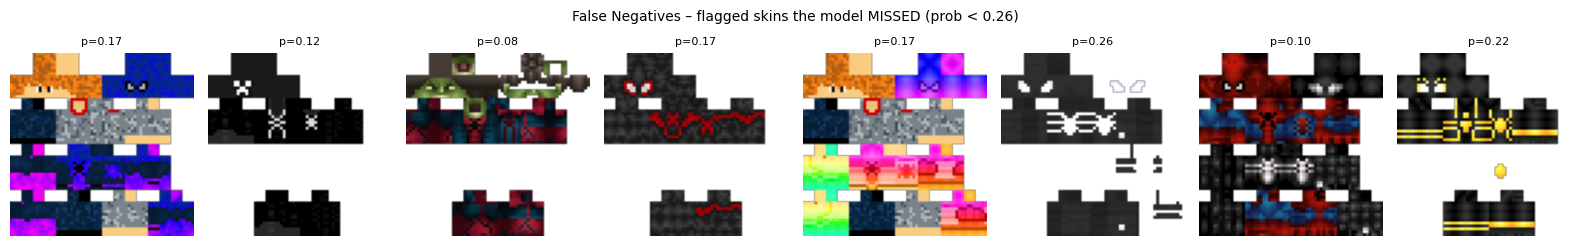

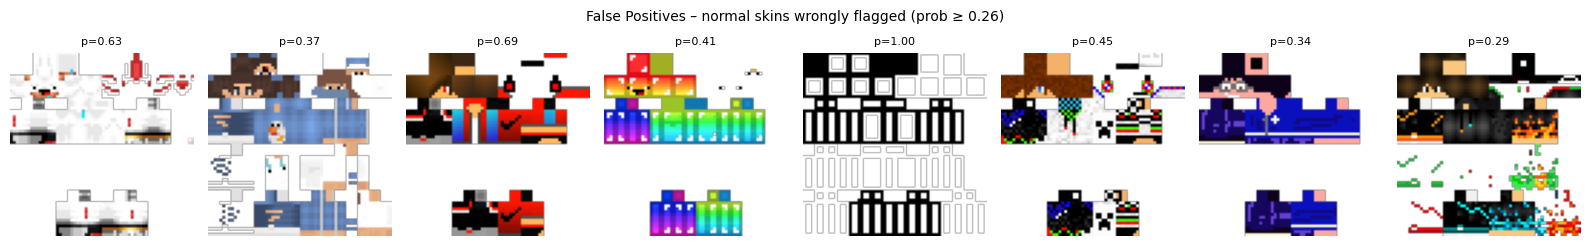

In [284]:
def show_errors(X_test, y_test, y_pred, y_prob, error_type="fn", n=8, threshold=0.5):
    """
    Show misclassified samples.
    error_type: 'fn' = false negatives (missed flagged skins)
                'fp' = false positives (normal skins wrongly flagged)
    """
    if error_type == "fn":
        mask  = (y_test == 1) & (y_pred == 0)
        title = f"False Negatives – flagged skins the model MISSED (prob < {threshold:.2f})"
    else:
        mask  = (y_test == 0) & (y_pred == 1)
        title = f"False Positives – normal skins wrongly flagged (prob ≥ {threshold:.2f})"

    indices = np.where(mask)[0]
    if len(indices) == 0:
        print(f"No {error_type.upper()} errors found!")
        return

    chosen = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    fig.suptitle(title, fontsize=10)
    if len(chosen) == 1:
        axes = [axes]
    for ax, idx in zip(axes, chosen):
        ax.imshow(X_test[idx, :, :, :4])
        ax.set_title(f"p={y_prob[idx]:.2f}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_errors(X_test, y_test.astype(int), y_pred_tuned, y_prob, error_type="fn", threshold=BEST_THRESH)
show_errors(X_test, y_test.astype(int), y_pred_tuned, y_prob, error_type="fp", threshold=BEST_THRESH)

---
## 18. Results Summary & Comparison

We compare all models / thresholds against the majority-class baseline.

In [285]:
from sklearn.metrics import precision_score, recall_score

def eval_row(name, y_true, y_pred, y_prob=None):
    row = {
        "Model": name,
        "Accuracy" : (y_pred == y_true).mean(),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC"      : roc_auc_score(y_true, y_prob) if y_prob is not None else "-",
    }
    return row

summary = pd.DataFrame([
    eval_row("Majority Baseline",       y_test.astype(int), baseline_preds),
    eval_row("CNN (threshold=0.5)",     y_test.astype(int), y_pred_default, y_prob),
    eval_row(f"CNN (threshold={BEST_THRESH:.3f})", y_test.astype(int), y_pred_tuned, y_prob),
])

# Format numeric columns
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    summary[col] = summary[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

print(summary.to_string(index=False))

                Model Accuracy Precision Recall     F1       AUC
    Majority Baseline   0.5000    0.0000 0.0000 0.0000         -
  CNN (threshold=0.5)   0.7833    0.8512 0.6867 0.7601  0.858222
CNN (threshold=0.265)   0.7500    0.7419 0.7667 0.7541  0.858222


---
## 19. Conclusion & Key Learnings

### What we built

A binary CNN classifier for Minecraft skin images (64×64 RGBA) that detects  
copyrighted/banned character skins with high reliability.

### Key design decisions and why they matter

| Decision | Impact |
|---|---|
| Keeping the **alpha channel** as input | Alpha encodes skin regions – structural information for the model |
| **Class weighting** | Counteracts imbalance without data duplication |
| **No flipping/rotation augmentation** | Preserves the fixed spatial structure of the skin format |
| **GlobalAveragePooling** instead of Flatten | Fewer parameters, less overfitting |
| **EarlyStopping + ReduceLROnPlateau** | Prevents overfitting, improves convergence stability |
| **Threshold tuning on validation set** | Optimises recall without leaking test set information |

### Limitations & future work

- Currently trained only on **Spider-Man** as the bad class → more keyword classes would improve generalization  
- **Focal Loss** could replace class weighting for even stronger handling of hard examples  
- **Hyperparameter search** (Bayesian optimisation) over dropout rates, LR, architecture depth  
- **Region-based CNN**: train separate heads for head, body, arms, legs regions (exploits known skin layout)  
- **Explainability**: Grad-CAM heatmaps to visualise which skin regions drive the prediction

In [56]:
# Save the final model
model.save(str(MODEL_PATH))
print(f"Model saved to: {MODEL_PATH}")

Model saved to: ..\04_Modelling\best_model.keras
